# AutoEncoders for Beginners

this is the most basic implementation of AutoEncoders. Building upon this project i have implemented Variational/Vanilla AutoEncoders (VAE). At the end of the notebook, you can find all the explaination of the functions that i have used and why i have use it.

(PS: I have used gemini to do explaination).

Thanks for reading

In [42]:
##libraries

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [43]:
##selecting the GPU or cpu devices
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [44]:
## training and val data
BATCH_SIZE = 128
data_transform = transforms.Compose([transforms.ToTensor()])

##dataset selection
train_dataset = datasets.FashionMNIST(root = "./data", train = True, transform = data_transform, download = True)
##data_loader
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)


Play with the values of Latent dimension and observe the graphs that we have coded below

In [45]:
##autoencoder

class AutoEncoder(nn.Module):
  def __init__(self, hidden_layer = 256, latent_dim = 1):
    super().__init__()

    ##Encoder
    self.encoder = nn.Sequential(
        nn.Linear( 784, hidden_layer),
        nn.ReLU(),
        nn.Linear(hidden_layer, latent_dim),
        nn.ReLU(),
    )

    ##Decoder
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, hidden_layer),
        nn.ReLU(),
        nn.Linear(hidden_layer, 784),
        nn.Sigmoid()
    )

  ##Forward Pass
  def forward(self, x):
      ##our latent is z
      z = self.encoder(x) ##encoded image
      x_reconstructed = self.decoder(z) ## reconstructed image
      return x_reconstructed ##this will not be an actual image but rather a vector that we will plot as an image using matplotlib

In [46]:
##defining the model and loss
model = AutoEncoder()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

Try different epochs to observe how the loss changes


In [47]:
epochs = 20

model.train()
for epoch in range(epochs):
  ##initialise the loss
  total_loss = 0
  for x, _ in train_loader:
    x = x.view(-1, 784).to(device)

    optimizer.zero_grad() ##for every new batch we are not considering the accumulated gradient
    x_reconstructed = model(x)
    loss = criterion(x_reconstructed, x)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
  avg_loss = total_loss/len(train_loader)
  print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss}")

Epoch 1/20, Loss: 0.03642891474099937
Epoch 2/20, Loss: 0.023416428558671397
Epoch 3/20, Loss: 0.022221492146695856
Epoch 4/20, Loss: 0.021550622111412763
Epoch 5/20, Loss: 0.02113633706514388
Epoch 6/20, Loss: 0.020843794525686358
Epoch 7/20, Loss: 0.020617397398805058
Epoch 8/20, Loss: 0.020417634302428538
Epoch 9/20, Loss: 0.02026188469676575
Epoch 10/20, Loss: 0.02011936095986031
Epoch 11/20, Loss: 0.02000746304498934
Epoch 12/20, Loss: 0.0199055752035842
Epoch 13/20, Loss: 0.01981156432171112
Epoch 14/20, Loss: 0.019726681791102964
Epoch 15/20, Loss: 0.019654103588543213
Epoch 16/20, Loss: 0.019593885851535462
Epoch 17/20, Loss: 0.019527913903249608
Epoch 18/20, Loss: 0.01946402738677032
Epoch 19/20, Loss: 0.019395096366530033
Epoch 20/20, Loss: 0.019355462375543774


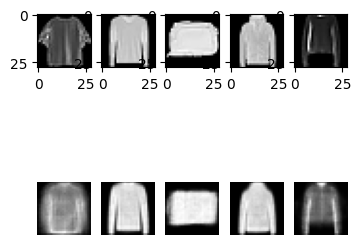

In [48]:
## setting the model in evaluation mode
model.eval()
## since for evaluation we dont need the gradients
with torch.no_grad():
  x, _ = next(iter(train_loader))##loading the data from the training data itself just to see how the reconstruction looks like
  x = x.view(-1, 784).to(device)
  ##forward pass
  x_reconstructed = model(x);

  n = 5
  plt.figure(figsize = (4, 4))
  for i in range(n):
    ##for the original image
    plt.subplot(2, n, i+1)
    plt.imshow(x[i].view(28,28), cmap = "gray")
    plt.axis("on")

    ##for the recinstructed image
    plt.subplot(2, n, i+1+n)
    plt.imshow(x_reconstructed[i].view(28,28), cmap="gray")
    plt.axis("off")

  plt.show()

In [49]:
##getting the latents
model.eval()

latents = []
labels = []

with torch.no_grad():
  for x, y in train_loader:
    x = x.view(-1, 784).to(device)
    z = model.encoder(x)

    latents.append(z.cpu())
    labels.append(y)

latents = torch.cat(latents, dim = 0)
labels = torch.cat(labels, dim = 0)


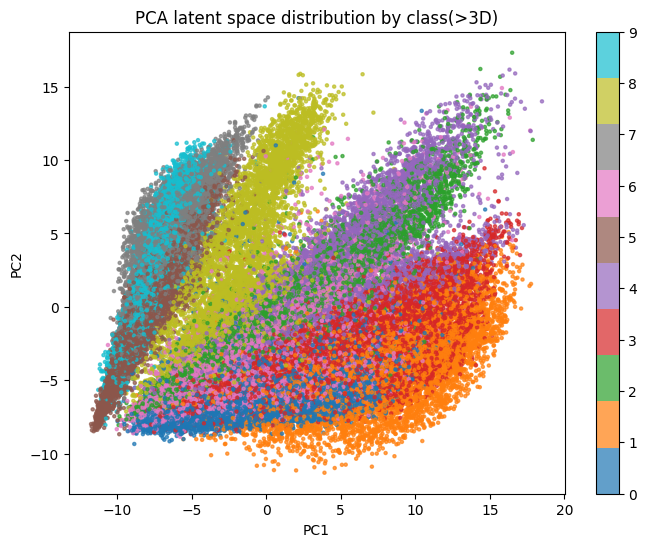

In [50]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

latent_dim = latents.shape[1]

##ensure numpy is imported
Z = latents.detach().cpu().numpy()
y = labels.detach().cpu().numpy()

if latent_dim == 1:
  ## 1d hist + strip plot
  plt.figure(figsize = (8, 4))
  for digit in range(10):
    plt.hist(
        Z[y == digit].flatten(),
        bins = 50,
        alpha = 0.5,
        label = str(digit)
    )
  plt.xlabel("latent value")
  plt.ylabel("frequency")
  plt.title("1D latent distribution by class")
  plt.legend()
  plt.show()

elif latent_dim == 2:
  ##2D scatter
  plt.figure(figsize = (8, 4))
  for digit in range(10):
    plt.scatter(
        Z[:, 0], Z[:, 1],
        c = y, cmap = "tab10",
        s = 5, alpha = 0.7,
        label = str(digit)
    )
  plt.colorbar(scatter, ticks = range(10))
  plt.xlabel("z1")
  plt.ylabel("z2")
  plt.title("2D latent space distribution by class")
  plt.legend()
  plt.show()

elif latent_dim == 3:
  ##3D rotatable scatter
  fig = plt.figure(figsize = (8,6))
  ax = fig.add_subplot(111, projection = "3d")
  scatter = ax.scatter(
      Z[:, 0], Z[:, 1], Z[:, 2],
      c = y, cmap = "tab10",
      s = 5, alpha = 0.7
  )

  ax.set_xlabel("z1")
  ax.set_ylabel("z2")
  ax.set_zlabel("z3")
  ax.set_title("3D latent space distribution by class")
  fig.colorbar(scatter, ticks = range(10))
  plt.show()

else:
  ##when higher than 3D space
  pca_dim = 2
  pca = PCA(n_components = pca_dim)
  Z_pca = pca.fit_transform(Z)

  if pca_dim == 2:
    plt.figure(figsize = (8,6))
    scatter = plt.scatter(
        Z_pca[:, 0], Z_pca[:, 1],
        c = y, cmap = "tab10",
        s = 5, alpha = 0.7
    )

    plt.colorbar(scatter, ticks = range(10))
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA latent space distribution by class(>3D)")
    plt.show()

  else:
    fig = plt.figure(figsize = (8,6))
    ax = fig.add_subplot(111, projection = "3d")
    scatter = ax.scatter(
        Z_pca[:, 0], Z_pca[:, 1], Z_pca[:, 2],
        c = y, cmap = "tab10",
        s = 5, alpha = 0.7
    )
    plt.colorbar(scatter, ticks = range(10))
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.zlabel("PC3")
    plt.title("PCA latent space distribution by class(>3D)")
    plt.show()


```markdown
Let's break down the code in the `if latent_dim == 1:` block line by line, in simple terms:

*   **`latent_dim = latents.shape[1]`**:
    *   **What it does**: This line figures out how many numbers are in each of your latent vectors. Think of it as checking the 'width' of your compressed data.
    *   **Why**: Your latent vectors (`latents`) are like a collection of compressed images. Each compressed image is a list of numbers. This line tells us how long that list is for one compressed image. For example, if each compressed image is represented by 64 numbers, `latent_dim` will be 64.

*   **`Z = latents.detach().cpu().numpy()`**:
    *   **What it does**: This converts your `latents` (which are special PyTorch numbers) into regular Python numbers that can be used by plotting tools like Matplotlib.
    *   **Why**: PyTorch tensors keep track of things for training, but for simple plotting, we just need the plain number values. `.detach()` removes the tracking info, `.cpu()` moves them from a GPU (if you're using one) to the main computer memory, and `.numpy()` turns them into a standard array of numbers that Matplotlib understands.

*   **`y = labels.detach().cpu().numpy()`**:
    *   **What it does**: Similar to `Z`, this converts your `labels` (which are also PyTorch numbers) into regular Python numbers.
    *   **Why**: You have a label (like '0' or '5') for each compressed image. We need these labels in a simple format to help us sort and visualize the latent vectors by their original digit.

Now, for the `if latent_dim == 1:` block itself:

*   **`if latent_dim == 1:`**:
    *   **What it does**: This is a check. It asks, "Is each of my compressed images represented by *just one* number?"
    *   **Why**: The code inside this block will only run if your latent space is indeed one-dimensional. This means your AutoEncoder is trying to compress each image into a single value. This specific visualization code is designed only for this 1D case.

*   **`plt.figure(figsize = (8, 4))`**:
    *   **What it does**: This creates a blank canvas (a 'figure') where your plot will be drawn.
    *   **Why**: You need a space to put your graph. `figsize = (8, 4)` just sets the size of this canvas to be 8 inches wide and 4 inches tall, which is a good starting size for a histogram.

*   **`for digit in range(10):`**:
    *   **What it does**: This starts a loop that will go through each possible digit, from 0 up to 9.
    *   **Why**: We want to see how the single latent number for '0's looks compared to '1's, '2's, and so on. This loop lets us process each digit's data separately.

*   **`plt.hist( ... )`**:
    *   **What it does**: This command draws a histogram for a specific digit. A histogram shows how frequently different values appear.
    *   **Why**: For each digit (e.g., all the '0's), we collect all their single latent numbers. Then, we plot these numbers to see if they tend to cluster in a certain range or if they are spread out. This helps us understand if the AutoEncoder is putting '0's in one area of the 1D space and '1's in another.

    *   **`Z[y == digit].flatten()`**:
        *   **What it does**: This selects only the latent numbers that belong to the current `digit` (e.g., all the latent numbers for the digit '0') and prepares them for the histogram.
        *   **Why**: We only want to plot the latent values for '0's when `digit` is '0', for '1's when `digit` is '1', etc.

    *   **`bins = 50`**:
        *   **What it does**: This tells the histogram to divide the range of latent values into 50 sections (or 'bins').
        *   **Why**: More bins give you a more detailed view of the distribution, while fewer bins give a more general overview. 50 is a common choice.

    *   **`alpha = 0.5`**:
        *   **What it does**: Makes each histogram bar slightly see-through.
        *   **Why**: Since we're plotting 10 different histograms on top of each other (one for each digit), making them transparent allows you to see where they overlap.

    *   **`label = str(digit)`**:
        *   **What it does**: Assigns a name (like "0", "1", etc.) to each histogram, which will appear in the legend.
        *   **Why**: So you can tell which color histogram belongs to which digit.

*   **`plt.xlabel("latent value")`**:
    *   **What it does**: Adds a label to the horizontal (bottom) axis of your plot.
    *   **Why**: To clearly indicate what the numbers on this axis represent (the compressed values).

*   **`plt.ylabel("frequency")`**:
    *   **What it does**: Adds a label to the vertical (left) axis of your plot.
    *   **Why**: To show that this axis represents how many times a certain latent value or range of values appeared.

*   **`plt.title("1D latent distribution by class")`**:
    *   **What it does**: Puts a main title at the top of your entire plot.
    *   **Why**: To give a clear summary of what the plot is showing.

*   **`plt.legend()`**:
    *   **What it does**: Displays the legend, which shows which color corresponds to which digit.
    *   **Why**: This is essential for understanding the different colored histograms on the plot.

*   **`plt.show()`**:
    *   **What it does**: Finally, this command displays the completed plot on your screen.
    *   **Why**: Without this, the plot is created in the background but won't actually be visible.

```markdown
Let's break down the code in the `elif latent_dim == 3:` block line by line, in simple terms:

*   **`elif latent_dim == 3:`**:
    *   **What it does**: This is a conditional check, meaning this block of code will only run if your `latent_dim` (the number of values representing each compressed image) is exactly 3.
    *   **Why**: This specific visualization method is designed for a 3-dimensional space. If `latent_dim` is 1 or 2, other `if/elif` blocks would handle the plotting. If it's greater than 3, a different method (like PCA, as seen in the `else` block) is needed.

*   **`fig = plt.figure(figsize = (8,6))`**:
    *   **What it does**: This creates a new, empty 'figure' or canvas where your plot will be drawn. `figsize=(8,6)` sets the size of this figure to be 8 inches wide and 6 inches tall.
    *   **Why**: You need a designated area for your plot. For a 3D plot, a slightly larger figure size often helps with readability.

*   **`ax = fig.add_subplot(111, projection = "3d")`**:
    *   **What it does**: This adds a 3D subplot (a set of axes) to your figure.
    *   **Explanation**:
        *   `fig.add_subplot(111)` is a shorthand for `fig.add_subplot(1, 1, 1)`, meaning "create a grid of 1 row by 1 column, and place this subplot in the first position." In this case, it means you'll have one main plot occupying the entire figure.
        *   `projection = "3d"` is the crucial part that tells Matplotlib to create a 3-dimensional set of axes, allowing you to plot points in 3D space.
    *   **Why**: You need a 3D coordinate system (axes) to draw your 3D points on.

*   **`scatter = ax.scatter( Z[:, 0], Z[:, 1], Z[:, 2], ... )`**:
    *   **What it does**: This is the core command that creates the 3D scatter plot.
    *   **Explanation**: It takes three arrays for the X, Y, and Z coordinates of each point.
        *   `Z[:, 0]` represents the first dimension of your latent vectors (`z1`).
        *   `Z[:, 1]` represents the second dimension (`z2`).
        *   `Z[:, 2]` represents the third dimension (`z3`).
        *   Each row in `Z` corresponds to one image's latent vector. So, this plots every latent vector as a point in 3D space.
    *   **Why**: This is how you visualize the distribution of your compressed data points.

    *   **`c = y`**:
        *   **What it does**: This assigns a color to each point based on its corresponding label (`y`).
        *   **Why**: By coloring the points according to their original digit (0-9), you can visually assess if the AutoEncoder has grouped similar digits together in the latent space. For example, if all '0's are blue and all '1's are red, and these colors form distinct clusters, it means the model is doing a good job.

    *   **`cmap = "tab10"`**:
        *   **What it does**: This specifies the colormap to use for assigning colors. "tab10" is a common colormap that provides 10 distinct colors, which is perfect for representing the 10 digits (0-9).
        *   **Why**: It ensures that each digit gets a unique, easily distinguishable color.

    *   **`s = 5`**:
        *   **What it does**: Sets the size of each scatter plot marker (point) to 5.
        *   **Why**: A small size prevents overcrowding, especially with many data points.

    *   **`alpha = 0.7`**:
        *   **What it does**: Sets the transparency (opacity) of each point to 0.7.
        *   **Why**: Making the points slightly transparent allows you to see overlapping points and density better, which is useful when many points cluster in the same area.

*   **`ax.set_xlabel("z1")`**:
    *   **What it does**: Labels the X-axis of the 3D plot as "z1".
    *   **Why**: To clearly indicate what the first latent dimension represents.

*   **`ax.set_ylabel("z2")`**:
    *   **What it does**: Labels the Y-axis of the 3D plot as "z2".
    *   **Why**: To clearly indicate what the second latent dimension represents.

*   **`ax.set_zlabel("z3")`**:
    *   **What it does**: Labels the Z-axis of the 3D plot as "z3".
    *   **Why**: To clearly indicate what the third latent dimension represents.

*   **`ax.set_title("3D latent space distribution by class")`**:
    *   **What it does**: Sets the main title of the 3D plot.
    *   **Why**: To provide a clear description of what the plot is showing.

*   **`fig.colorbar(scatter, ticks = range(10))`**:
    *   **What it does**: Adds a color bar next to the plot.
    *   **Explanation**: This color bar serves as a legend, showing which color corresponds to which digit label (0-9). `ticks = range(10)` ensures that the color bar explicitly labels all 10 digits.
    *   **Why**: Essential for interpreting the colors in the scatter plot and understanding which digit each cluster represents.

*   **`plt.show()`**:
    *   **What it does**: Displays the generated 3D plot.
    *   **Why**: Without this command, the plot would be created in the background but not rendered visibly.